# Quantum_FL_RS_general_Ne_Nx

Clean generalized notebook for comparing the many-body Qiskit evolution with the Raffelt--Sigl mean-field evolution for

\[
N_e\;\nu_e + N_x\;\nu_x(\alpha),
\qquad
\nu_x(\alpha)=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu .
\]

This is the generalized version of the older fixed \(1\nu_e+15\nu_x\) notebook.

Default choice:

\[
N_e=1,\qquad N_x=15.
\]

To check \(N_e=2\) later, change only `Ne` in Cell 1.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integ

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

In [32]:
import argparse

parser = argparse.ArgumentParser(
    description="Many-body vs Random-Phase neutrino oscillation simulation"
)

parser.add_argument(
    "--Ne",
    type=int,
    help="Number of initially electron-flavor neutrinos",
)

parser.add_argument(
    "--Nx",
    type=int,
    help="Number of initially x-flavor neutrinos",
)

args, _ = parser.parse_known_args()

if args.Ne is None:
    Ne = int(input("Enter the number of electron-flavor neutrinos (Ne): "))
else:
    Ne = args.Ne

if args.Nx is None:
    Nx = int(input("Enter the number of x-flavor neutrinos (Nx): "))
else:
    Nx = args.Nx

N = Ne + Nx

if Ne < 1 or Nx < 1:
    raise ValueError("Ne and Nx must be positive integers.")

Enter the number of electron-flavor neutrinos (Ne):  1
Enter the number of x-flavor neutrinos (Nx):  8


In [33]:
# =============================
# CELL 1: Imports and parameters
# =============================


# -----------------------------
# Physics parameters
# -----------------------------
E = 1.0
dm2 = 1.0
theta_vac = 0.195

sin_2th = np.sin(2.0 * theta_vac)
cos_2th = np.cos(2.0 * theta_vac)
omega1 = dm2 / (4.0 * E)

bx = omega1 * np.sin(2.0 * theta_vac)
by = 0.0
bz = -omega1 * np.cos(2.0 * theta_vac)

# This is the scale used for the dimensionless time axis t*mu.
mu = omega1 * N

# -----------------------------
# Evolution choices
# -----------------------------
# Keep these False to match the later cells of the old e1_x15 notebook:
# self-interaction only, with no vacuum and no matter term.
use_vacuum = False
use_matter = False

# -----------------------------
# Time / Trotter / sampling parameters
# -----------------------------
dt = 0.5
T_max = 200.0
sample_every = 20

n_steps_max = int(round(T_max / dt))
times = np.arange(0, n_steps_max + 1, sample_every) * dt

# -----------------------------
# Qiskit simulation parameters
# -----------------------------
shots = 4096
seed_simulator = 12345
backend = AerSimulator(
            method="matrix_product_state",
            matrix_product_state_max_bond_dimension=16,
            matrix_product_state_truncation_threshold=1e-8,

    # Temporary workaround for Aer's false preflight estimate.
            max_memory_mb=8_000_000,
            seed_simulator=seed_simulator,
        )

# -----------------------------
# Alpha cases
# -----------------------------
alpha_cases = [
    (np.pi/2, r"\pi/2"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
    (0.0,     r"0"),
]

print(f"Using Ne = {Ne}, Nx = {Nx}, total N = {N}")
print(f"omega1 = {omega1}")
print(f"mu = omega1 * N = {mu}")
print(f"Number of sampled times = {len(times)}, T_max = {T_max}, dt = {dt}")
print(f"Evolution mode: self-interaction only = {not use_vacuum and not use_matter}")

Using Ne = 1, Nx = 8, total N = 9
omega1 = 0.25
mu = omega1 * N = 2.25
Number of sampled times = 21, T_max = 200.0, dt = 0.5
Evolution mode: self-interaction only = True


In [34]:
# =======================================
# CELL 2: Interaction matrix J_ij
# =======================================

def interaction_matrix(N, dm2, E):
    """
    Build Jij = (dm2 / 4E) * (1 - cos(theta_ij)),
    with theta_ij = arccos(0.9) * |i-j|/(N-1).

    This is the same interaction matrix used in the old e1_x15 notebook.
    """
    i = np.arange(N)
    dij = np.abs(i[:, None] - i[None, :])

    if N == 1:
        return np.zeros((1, 1))

    theta_ij = np.arccos(0.9) * dij / (N - 1)
    J = (dm2 / (4.0 * E)) * (1.0 - np.cos(theta_ij))

    # Alternative toy choice from the old notebook:
    # J = np.ones((N, N))

    return J

J = interaction_matrix(N, dm2, E)
print("J shape =", J.shape)
print("J min/max =", J.min(), J.max())

J shape = (9, 9)
J min/max = 0.0 0.024999999999999994


In [35]:
# =========================================
# CELL 3: Qiskit evolution building blocks
# =========================================

def add_vacuum_evolution(qc, n, bx, by, bz, N):
    """
    Add n first-order vacuum steps to the circuit.

    This function is retained for completeness, but use_vacuum=False by default
    to match the old e1_x15 comparison.
    """
    for _ in range(n):
        for q in range(N):
            qc.rx(2.0 * bx, q)
            qc.ry(2.0 * by, q)
            qc.rz(2.0 * bz, q)


def add_interaction_evolution(qc, n, J, N, dt):
    """
    Add n first-order interaction steps to the circuit.

    For each pair (i,j), apply approximately

        exp[-i Jij dt (XX + YY + ZZ)]

    using

        RXX(2 Jij dt) RYY(2 Jij dt) RZZ(2 Jij dt).
    """
    for _ in range(n):
        for i in range(N):
            for j in range(i + 1, N):
                phi = 2.0 * J[i, j] * dt
                qc.rxx(phi, i, j)
                qc.ryy(phi, i, j)
                qc.rzz(phi, i, j)

In [36]:
# ============================================
# CELL 4: Raffelt--Sigl mean-field solver
# ============================================

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]], dtype=complex)
sigma_1 = np.array([[0, 1],  [1,  0]], dtype=complex)
sigma_2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_3 = np.array([[1, 0],  [0, -1]], dtype=complex)


def P_osc_RS(t_table, theta, omega, lam, J, initial_flavors=None, alpha=None):
    """
    Raffelt--Sigl two-flavor polarization-vector evolution.

    Parameters
    ----------
    t_table : array
        Sampled times.
    theta : float
        Vacuum mixing angle.
    omega : array
        Vacuum frequencies for all modes.
    lam : float
        Matter strength.
    J : array
        Coupling matrix.
    initial_flavors : array
        Entries may be:
            'e'  : |nu_e>
            'x'  : |nu_mu>
            'mu' : |nu_mu>
            'a'  : cos(alpha)|nu_e> + sin(alpha)|nu_mu>
    alpha : float
        Superposition angle for every mode labeled 'a'.
    """
    n_modes = J.shape[0]

    u = np.array([[np.cos(theta), np.sin(theta)],
                  [-np.sin(theta), np.cos(theta)]])
    b = 0.5 * np.diag([-1, 1])
    b = u @ b @ u.T
    l = np.diag([1, 0])

    Ee = np.array([0.0, 0.0,  1.0])
    Emu = np.array([0.0, 0.0, -1.0])

    B = np.real(np.array([np.trace(b @ sigma_1),
                          np.trace(b @ sigma_2),
                          np.trace(b @ sigma_3)]))
    L = np.real(np.array([np.trace(l @ sigma_1),
                          np.trace(l @ sigma_2),
                          np.trace(l @ sigma_3)]))

    ini_state = np.where(omega > 0, Ee[:, None], Emu[:, None])

    if initial_flavors is not None:
        initial_flavors = np.asarray(initial_flavors)

        for f in initial_flavors:
            if f not in ["e", "x", "mu", "a"]:
                raise ValueError(f"Unknown flavor label: {f}")
            if f == "a" and alpha is None:
                raise ValueError("Flavor label 'a' requires alpha.")

        ini_state[:, initial_flavors == "e"] = Ee[:, None]
        ini_state[:, initial_flavors == "x"] = Emu[:, None]
        ini_state[:, initial_flavors == "mu"] = Emu[:, None]
        ini_state[:, initial_flavors == "a"] = np.array(
            [np.sin(2.0 * alpha), 0.0, np.cos(2.0 * alpha)]
        )[:, None]

    def rhs(t, P_flat):
        """
        dP_k/dt = H_k x P_k,
        H_k = omega_k B + lambda L + sum_j J_kj P_j.
        """
        res = np.zeros(3 * n_modes)
        PP = np.reshape(P_flat, (n_modes, 3)).T

        for k in range(n_modes):
            H_k = omega[k] * B + lam * L + PP @ J[k, :]
            res[3*k:3*k+3] = np.cross(H_k, PP[:, k])

        return res

    return integ.solve_ivp(
        rhs,
        (t_table[0], t_table[-1]),
        ini_state.T.flatten(),
        t_eval=t_table,
    )

In [37]:
# =====================================================
# CELL 5: Many-body Qiskit solver for Ne + Nx(alpha)
# =====================================================

def prepare_initial_circuit(Ne, Nx, alpha):
    """
    Prepare the initial many-body state:

        first Ne qubits: |nu_e> = |0>
        next  Nx qubits: |nu_x(alpha)> = cos(alpha)|0> + sin(alpha)|1>

    RY(2 alpha)|0> = cos(alpha)|0> + sin(alpha)|1>.

    For alpha = pi/2, the Nx group is exactly |1>, reproducing
    the old 1 nu_e + 15 nu_mu setup when Ne=1, Nx=15.
    """
    N = Ne + Nx
    qc0 = QuantumCircuit(N, N)

    # First Ne qubits are |nu_e> = |0>, so no gate is needed.
    for q in range(Ne, N):
        qc0.ry(2.0 * alpha, q)

    return qc0


def run_many_body_qiskit(alpha, Ne, Nx, J, times, dt, shots, backend,
                         use_vacuum=False, bx=0.0, by=0.0, bz=0.0,
                         verbose=True):
    """
    Run the many-body Qiskit simulation for a given alpha.

    Output
    ------
    P_bit1[q, k] :
        Probability that qubit q is measured as |1> at time times[k].

    For the first Ne qubits, which start as |nu_e>=|0>,
        P_bit1 = P(nu_e -> nu_mu).

    The plotted observable is the Ne-average:
        <P(nu_e -> nu_mu)> over the initially electron-flavor group.
    """
    N = Ne + Nx
    qc0 = prepare_initial_circuit(Ne, Nx, alpha)

    P_bit1 = [[] for _ in range(N)]

    for t in times:
        n = int(round(t / dt))
        qc = qc0.copy()

        if use_vacuum:
            add_vacuum_evolution(qc, n=n, bx=bx, by=by, bz=bz, N=N)

        add_interaction_evolution(qc, n=n, J=J, N=N, dt=dt)

        qc.measure(range(N), range(N))

        tqc = transpile(qc, backend, optimization_level=0)
        counts = backend.run(tqc, shots=shots).result().get_counts()

        p1_t = [0.0] * N

        for bitstring, c in counts.items():
            prob = c / shots

            for q in range(N):
                # Qiskit displays bitstrings with the highest classical bit first.
                bit_q = int(bitstring[-1 - q])
                if bit_q == 1:
                    p1_t[q] += prob

        for q in range(N):
            P_bit1[q].append(p1_t[q])

        if verbose:
            print(
                f"alpha={alpha:.6f}, t={t:8.3f}: "
                f"<P_e_to_mu>_MB = {np.mean(p1_t[:Ne]):.5f}"
            )

    P_bit1 = np.array(P_bit1)

    return {
        "P_bit1": P_bit1,
        "P_e_to_mu_avg": np.mean(P_bit1[:Ne, :], axis=0),
    }

In [38]:
# =====================================================
# CELL 6: RS solver and combined alpha-case runner
# =====================================================

def run_rs_mean_field(alpha, Ne, Nx, J, times,
                      use_vacuum=False, use_matter=False):
    """
    Run the Raffelt--Sigl mean-field evolution for the same initial state.

    Default:
        omega = 0,
        lambda = 0,

    so this solves the self-interaction-only mean-field problem, matching
    the old e1_x15 comparison.
    """
    N = Ne + Nx

    if use_vacuum:
        omega = np.ones(N) * omega1
        theta_rs = theta_vac
    else:
        omega = np.zeros(N)
        theta_rs = 0.0

    lam = 1.0 if use_matter else 0.0

    initial_flavors = np.array(["e"] * Ne + ["a"] * Nx)

    sol = P_osc_RS(
        times,
        theta_rs,
        omega,
        lam,
        J,
        initial_flavors=initial_flavors,
        alpha=alpha,
    )

    P_all = sol.y
    P = P_all.reshape(N, 3, -1)
    Pz = P[:, 2, :]

    # P(nu_mu) = (1 - Pz)/2 for each mode.
    P_mu = 0.5 * (1.0 - Pz)

    return {
        "sol": sol,
        "P": P,
        "Pz": Pz,
        "P_mu": P_mu,
        "P_e_to_mu_avg": np.mean(P_mu[:Ne, :], axis=0),
    }


def run_alpha_case(alpha, verbose=True):
    """
    Run both many-body Qiskit and RS mean-field for one alpha.
    """
    N = Ne + Nx
    J_local = interaction_matrix(N, dm2, E)

    mb = run_many_body_qiskit(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J_local,
        times=times,
        dt=dt,
        shots=shots,
        backend=backend,
        use_vacuum=use_vacuum,
        bx=bx,
        by=by,
        bz=bz,
        verbose=verbose,
    )

    rs = run_rs_mean_field(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J_local,
        times=times,
        use_vacuum=use_vacuum,
        use_matter=use_matter,
    )

    return {
        "alpha": alpha,
        "Ne": Ne,
        "Nx": Nx,
        "many_body": mb,
        "rs": rs,
    }

In [39]:
# =====================================================
# CELL 7: Plotting helpers
# =====================================================

results = {}

# Choose the x-axis used in all plots.
# Options:
#     "t"    : physical notebook time
#     "t_mu" : dimensionless t*mu
plot_time_axis = "t_mu"


def get_plot_time():
    if plot_time_axis == "t":
        return times, r"Total time"
    elif plot_time_axis == "t_mu":
        return times * mu, r"$t\mu$"
    else:
        raise ValueError("plot_time_axis must be either 't' or 't_mu'.")


def run_and_plot_alpha(alpha, alpha_label, fig_no=None, verbose=True, show_plot=True):
    """
    Run one alpha case and optionally plot the average conversion probability
    of the initially electron-flavor group.
    """
    key = alpha_label
    result = run_alpha_case(alpha, verbose=verbose)
    results[key] = result

    if show_plot:
        P_mb = result["many_body"]["P_e_to_mu_avg"]
        P_rs = result["rs"]["P_e_to_mu_avg"]

        x, xlabel = get_plot_time()

        plt.figure(figsize=(9, 5.5))

        plt.plot(
            x,
            P_mb,
            marker="o",
            linestyle="dashed",
            label=rf"Many-body Qiskit, $\alpha={alpha_label}$",
        )

        plt.plot(
            x,
            P_rs,
            linestyle="-",
            linewidth=2,
            label=rf"RS mean field, $\alpha={alpha_label}$",
        )

        plt.xlabel(xlabel)
        plt.ylabel(r"$\langle P(\nu_e\to\nu_\mu)\rangle_{N_e}$")

        if fig_no is None:
            plt.title(
                rf"$N_e={Ne}$, $N_x={Nx}$, "
                rf"$\nu_x=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu$"
            )
        else:
            plt.title(
                rf"Fig. {fig_no}: $N_e={Ne}$, $N_x={Nx}$, "
                rf"$\nu_x=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu$"
            )

        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return result

## Figures for different \(\alpha\)

Each cell below runs one \(\alpha\) case and produces one figure.

The plotted observable is the average conversion probability of the initially electron-flavor group:

\[
\left\langle P(\nu_e\rightarrow \nu_\mu)\right\rangle_{N_e}.
\]

In [40]:
# =============================
# CELL 8 / FIG. 1: alpha = pi/2
# =============================

fig1 = run_and_plot_alpha(np.pi/2, r"\pi/2", fig_no=1, verbose=True, show_plot=False)

alpha=1.570796, t=   0.000: <P_e_to_mu>_MB = 0.00000
alpha=1.570796, t=  10.000: <P_e_to_mu>_MB = 0.40991
alpha=1.570796, t=  20.000: <P_e_to_mu>_MB = 0.84912
alpha=1.570796, t=  30.000: <P_e_to_mu>_MB = 0.96484
alpha=1.570796, t=  40.000: <P_e_to_mu>_MB = 0.92773
alpha=1.570796, t=  50.000: <P_e_to_mu>_MB = 0.52612
alpha=1.570796, t=  60.000: <P_e_to_mu>_MB = 0.46094
alpha=1.570796, t=  70.000: <P_e_to_mu>_MB = 0.53369
alpha=1.570796, t=  80.000: <P_e_to_mu>_MB = 0.45850
alpha=1.570796, t=  90.000: <P_e_to_mu>_MB = 0.82446
alpha=1.570796, t= 100.000: <P_e_to_mu>_MB = 0.99609
alpha=1.570796, t= 110.000: <P_e_to_mu>_MB = 0.92358
alpha=1.570796, t= 120.000: <P_e_to_mu>_MB = 0.82300
alpha=1.570796, t= 130.000: <P_e_to_mu>_MB = 0.41895
alpha=1.570796, t= 140.000: <P_e_to_mu>_MB = 0.48145
alpha=1.570796, t= 150.000: <P_e_to_mu>_MB = 0.78564
alpha=1.570796, t= 160.000: <P_e_to_mu>_MB = 0.78711
alpha=1.570796, t= 170.000: <P_e_to_mu>_MB = 0.95972
alpha=1.570796, t= 180.000: <P_e_to_mu>_MB = 0

In [41]:
# =============================
# CELL 9 / FIG. 2: alpha = pi/3
# =============================

fig2 = run_and_plot_alpha(np.pi/3, r"\pi/3", fig_no=2, verbose=True, show_plot=False)

alpha=1.047198, t=   0.000: <P_e_to_mu>_MB = 0.00000
alpha=1.047198, t=  10.000: <P_e_to_mu>_MB = 0.56104
alpha=1.047198, t=  20.000: <P_e_to_mu>_MB = 0.82568
alpha=1.047198, t=  30.000: <P_e_to_mu>_MB = 0.68311
alpha=1.047198, t=  40.000: <P_e_to_mu>_MB = 0.70996
alpha=1.047198, t=  50.000: <P_e_to_mu>_MB = 0.31445
alpha=1.047198, t=  60.000: <P_e_to_mu>_MB = 0.58667
alpha=1.047198, t=  70.000: <P_e_to_mu>_MB = 0.78223
alpha=1.047198, t=  80.000: <P_e_to_mu>_MB = 0.31714
alpha=1.047198, t=  90.000: <P_e_to_mu>_MB = 0.60767
alpha=1.047198, t= 100.000: <P_e_to_mu>_MB = 0.73804
alpha=1.047198, t= 110.000: <P_e_to_mu>_MB = 0.69556
alpha=1.047198, t= 120.000: <P_e_to_mu>_MB = 0.81665
alpha=1.047198, t= 130.000: <P_e_to_mu>_MB = 0.29492
alpha=1.047198, t= 140.000: <P_e_to_mu>_MB = 0.44629
alpha=1.047198, t= 150.000: <P_e_to_mu>_MB = 0.84839
alpha=1.047198, t= 160.000: <P_e_to_mu>_MB = 0.53223
alpha=1.047198, t= 170.000: <P_e_to_mu>_MB = 0.69824
alpha=1.047198, t= 180.000: <P_e_to_mu>_MB = 0

In [42]:
# ==============================
# CELL 10 / FIG. 3: alpha = pi/4
# ==============================

fig3 = run_and_plot_alpha(np.pi/4, r"\pi/4", fig_no=3, verbose=True, show_plot=False)

alpha=0.785398, t=   0.000: <P_e_to_mu>_MB = 0.00000
alpha=0.785398, t=  10.000: <P_e_to_mu>_MB = 0.53369
alpha=0.785398, t=  20.000: <P_e_to_mu>_MB = 0.67529
alpha=0.785398, t=  30.000: <P_e_to_mu>_MB = 0.41650
alpha=0.785398, t=  40.000: <P_e_to_mu>_MB = 0.46997
alpha=0.785398, t=  50.000: <P_e_to_mu>_MB = 0.15356
alpha=0.785398, t=  60.000: <P_e_to_mu>_MB = 0.54004
alpha=0.785398, t=  70.000: <P_e_to_mu>_MB = 0.77515
alpha=0.785398, t=  80.000: <P_e_to_mu>_MB = 0.18701
alpha=0.785398, t=  90.000: <P_e_to_mu>_MB = 0.38428
alpha=0.785398, t= 100.000: <P_e_to_mu>_MB = 0.46729
alpha=0.785398, t= 110.000: <P_e_to_mu>_MB = 0.45264
alpha=0.785398, t= 120.000: <P_e_to_mu>_MB = 0.67554
alpha=0.785398, t= 130.000: <P_e_to_mu>_MB = 0.17529
alpha=0.785398, t= 140.000: <P_e_to_mu>_MB = 0.35815
alpha=0.785398, t= 150.000: <P_e_to_mu>_MB = 0.73804
alpha=0.785398, t= 160.000: <P_e_to_mu>_MB = 0.32056
alpha=0.785398, t= 170.000: <P_e_to_mu>_MB = 0.43823
alpha=0.785398, t= 180.000: <P_e_to_mu>_MB = 0

In [43]:
# ==============================
# CELL 11 / FIG. 4: alpha = pi/6
# ==============================

fig4 = run_and_plot_alpha(np.pi/6, r"\pi/6", fig_no=4, verbose=True, show_plot=False)

alpha=0.523599, t=   0.000: <P_e_to_mu>_MB = 0.00000
alpha=0.523599, t=  10.000: <P_e_to_mu>_MB = 0.34497
alpha=0.523599, t=  20.000: <P_e_to_mu>_MB = 0.39209
alpha=0.523599, t=  30.000: <P_e_to_mu>_MB = 0.19336
alpha=0.523599, t=  40.000: <P_e_to_mu>_MB = 0.23804
alpha=0.523599, t=  50.000: <P_e_to_mu>_MB = 0.05396
alpha=0.523599, t=  60.000: <P_e_to_mu>_MB = 0.34448
alpha=0.523599, t=  70.000: <P_e_to_mu>_MB = 0.50757
alpha=0.523599, t=  80.000: <P_e_to_mu>_MB = 0.08496
alpha=0.523599, t=  90.000: <P_e_to_mu>_MB = 0.18774
alpha=0.523599, t= 100.000: <P_e_to_mu>_MB = 0.22583
alpha=0.523599, t= 110.000: <P_e_to_mu>_MB = 0.22266
alpha=0.523599, t= 120.000: <P_e_to_mu>_MB = 0.39526
alpha=0.523599, t= 130.000: <P_e_to_mu>_MB = 0.08228
alpha=0.523599, t= 140.000: <P_e_to_mu>_MB = 0.20679
alpha=0.523599, t= 150.000: <P_e_to_mu>_MB = 0.44507
alpha=0.523599, t= 160.000: <P_e_to_mu>_MB = 0.13867
alpha=0.523599, t= 170.000: <P_e_to_mu>_MB = 0.21191
alpha=0.523599, t= 180.000: <P_e_to_mu>_MB = 0

alpha=0.000000, t=   0.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t=  10.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t=  20.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t=  30.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t=  40.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t=  50.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t=  60.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t=  70.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t=  80.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t=  90.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t= 100.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t= 110.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t= 120.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t= 130.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t= 140.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t= 150.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t= 160.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t= 170.000: <P_e_to_mu>_MB = 0.00000
alpha=0.000000, t= 180.000: <P_e_to_mu>_MB = 0

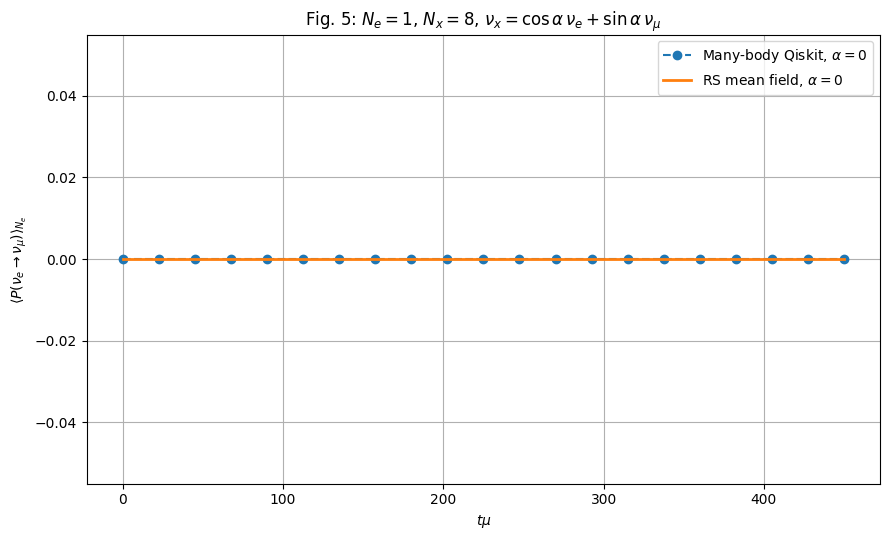

In [45]:
# ===========================
# CELL 12 / FIG. 5: alpha = 0
# ===========================

fig5 = run_and_plot_alpha(0.0, r"0", fig_no=5, verbose=True)

alpha=1.570796, t=   0.000: <P_e_to_mu>_MB = 0.00000
alpha=1.570796, t=  10.000: <P_e_to_mu>_MB = 0.40991
alpha=1.570796, t=  20.000: <P_e_to_mu>_MB = 0.84912
alpha=1.570796, t=  30.000: <P_e_to_mu>_MB = 0.96484
alpha=1.570796, t=  40.000: <P_e_to_mu>_MB = 0.92773
alpha=1.570796, t=  50.000: <P_e_to_mu>_MB = 0.52612
alpha=1.570796, t=  60.000: <P_e_to_mu>_MB = 0.46094
alpha=1.570796, t=  70.000: <P_e_to_mu>_MB = 0.53369
alpha=1.570796, t=  80.000: <P_e_to_mu>_MB = 0.45850
alpha=1.570796, t=  90.000: <P_e_to_mu>_MB = 0.82446
alpha=1.570796, t= 100.000: <P_e_to_mu>_MB = 0.99609
alpha=1.570796, t= 110.000: <P_e_to_mu>_MB = 0.92358
alpha=1.570796, t= 120.000: <P_e_to_mu>_MB = 0.82300
alpha=1.570796, t= 130.000: <P_e_to_mu>_MB = 0.41895
alpha=1.570796, t= 140.000: <P_e_to_mu>_MB = 0.48145
alpha=1.570796, t= 150.000: <P_e_to_mu>_MB = 0.78564
alpha=1.570796, t= 160.000: <P_e_to_mu>_MB = 0.78711
alpha=1.570796, t= 170.000: <P_e_to_mu>_MB = 0.95972
alpha=1.570796, t= 180.000: <P_e_to_mu>_MB = 0

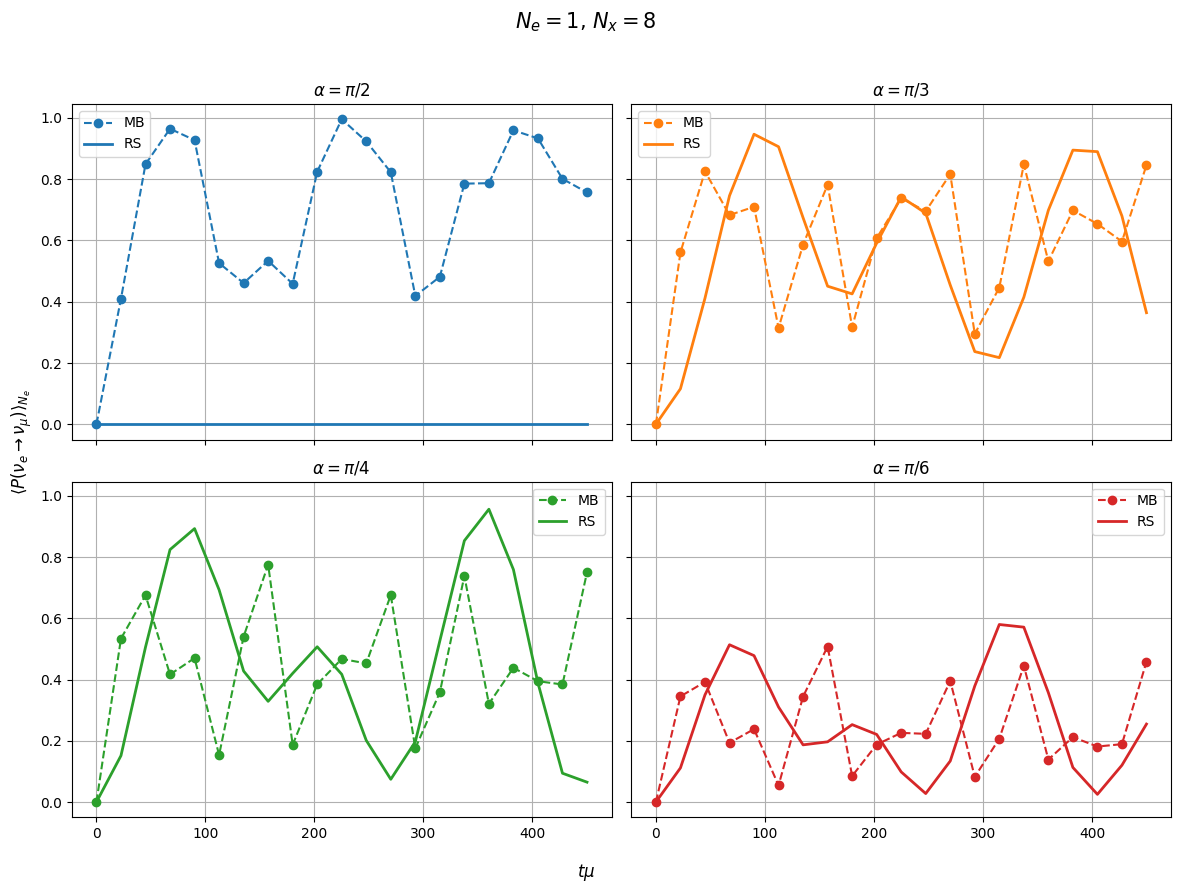

In [46]:
alpha_cases = [
    (np.pi/2, r"\pi/2"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes = axes.flatten()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, (alpha, alpha_label), color in zip(axes, alpha_cases, colors):

    result = run_and_plot_alpha(
        alpha,
        alpha_label,
        show_plot=False,
    )

    P_mb = result["many_body"]["P_e_to_mu_avg"]
    P_rs = result["rs"]["P_e_to_mu_avg"]

    x, xlabel = get_plot_time()

    ax.plot(x, P_mb, "--o", color=color, label="MB")
    ax.plot(x, P_rs, "-", lw=2, color=color, label="RS")

    ax.set_title(rf"$\alpha={alpha_label}$")
    ax.grid(True)
    ax.legend()

fig.supxlabel(xlabel)
fig.supylabel(r"$\langle P(\nu_e\to\nu_\mu)\rangle_{N_e}$")
fig.suptitle(rf"$N_e={Ne}$, $N_x={Nx}$", fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [47]:
# ============================================================
# CELL 14: Hilbert amplitude and frequency helper functions
# ============================================================

from scipy.signal import hilbert, savgol_filter


def hilbert_amp_omega(x, y, smooth=True):
    """
    Compute Hilbert envelope amplitude and instantaneous angular frequency.

    x : time variable used for the frequency derivative.
        Use either t or t*mu.
    y : signal, e.g. <P(nu_e -> nu_mu)>.

    Returns:
        amp(x)
        omega_inst(x) = d phase / dx
        centered signal
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_center = y - np.mean(y)

    # Light smoothing, useful for shot-noisy many-body curves.
    if smooth and len(y_center) >= 7:
        window = min(9, len(y_center))

        if window % 2 == 0:
            window -= 1

        if window >= 5:
            y_center = savgol_filter(
                y_center,
                window_length=window,
                polyorder=2,
            )

    if np.max(np.abs(y_center)) < 1.0e-12:
        amp = np.zeros_like(y_center)
        omega_inst = np.full_like(y_center, np.nan)
        return amp, omega_inst, y_center

    analytic_signal = hilbert(y_center)

    amp = np.abs(analytic_signal)
    phase = np.unwrap(np.angle(analytic_signal))
    omega_inst = np.gradient(phase, x)

    return amp, omega_inst, y_center


def representative_amp_omega(x, y, edge_fraction=0.10):
    """
    Compress the Hilbert amplitude/frequency into one representative number.

    We remove early/late edge regions because the Hilbert transform has
    edge artifacts.

    Amplitude:
        median envelope in the central region.

    Frequency:
        median instantaneous angular frequency in the central region,
        excluding points where the Hilbert envelope is too small.
    """

    amp, omega_inst, y_center = hilbert_amp_omega(x, y, smooth=True)

    n = len(x)

    i0 = int(edge_fraction * n)
    i1 = int((1.0 - edge_fraction) * n)

    if i1 <= i0:
        i0 = 0
        i1 = n

    central = np.zeros(n, dtype=bool)
    central[i0:i1] = True

    if np.nanmax(amp) > 0:
        amp_mask = amp > 0.15 * np.nanmax(amp)
    else:
        amp_mask = np.zeros(n, dtype=bool)

    freq_mask = central & amp_mask & np.isfinite(omega_inst)

    A_rep = np.nanmedian(amp[central])

    if np.any(freq_mask):
        omega_rep = np.nanmedian(omega_inst[freq_mask])
    else:
        omega_rep = np.nan

    return A_rep, omega_rep

In [48]:
# ============================================================
# CELL 15: Scan Nx and compute amplitude/frequency vs N
# ============================================================
# This cell runs the many-body and RS simulations directly.
# Nothing is saved to file.

# -----------------------------
# Choose scan
# -----------------------------
fixed_Ne = Ne

Nx_scan = np.arange(1, Nx + 1, 1)
# Later for Ne = 2:
# fixed_Ne = 2
# Nx_scan = np.arange(1, 11, 1)

# Choose alpha values to include.
# You can reduce this list to make the scan faster.
hilbert_alpha_cases = [
    (np.pi/2, r"\pi/2"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
]

# Do not include alpha = 0 for Hilbert frequency.
# The signal can be nearly flat, making the phase/frequency meaningless.

# -----------------------------
# Frequency axis
# -----------------------------
# "t_mu" gives angular frequency with respect to t*mu.
# "t"    gives angular frequency with respect to physical notebook time t.
hilbert_time_axis = "t_mu"

amp_freq_records = []

for Nx_here in Nx_scan:

    Ne_here = fixed_Ne
    N_here = Ne_here + Nx_here
    mu_here = omega1 * N_here

    J_here = interaction_matrix(N_here, dm2, E)

    print()
    print("=" * 70)
    print(f"Running Ne = {Ne_here}, Nx = {Nx_here}, Ntot = {N_here}")
    print("=" * 70)

    if hilbert_time_axis == "t_mu":
        x_h = times * mu_here
        x_label_h = r"$t\mu$"
        omega_label_h = r"$\omega_{\rm H}$ in units of $(t\mu)^{-1}$"
    elif hilbert_time_axis == "t":
        x_h = times
        x_label_h = r"$t$"
        omega_label_h = r"$\omega_{\rm H}$ in units of $t^{-1}$"
    else:
        raise ValueError("hilbert_time_axis must be 't_mu' or 't'.")

    for alpha_value, alpha_label in hilbert_alpha_cases:

        print(f"alpha = {alpha_label}")

        mb = run_many_body_qiskit(
            alpha=alpha_value,
            Ne=Ne_here,
            Nx=Nx_here,
            J=J_here,
            times=times,
            dt=dt,
            shots=shots,
            backend=backend,
            use_vacuum=use_vacuum,
            bx=bx,
            by=by,
            bz=bz,
            verbose=False,
        )

        rs = run_rs_mean_field(
            alpha=alpha_value,
            Ne=Ne_here,
            Nx=Nx_here,
            J=J_here,
            times=times,
            use_vacuum=use_vacuum,
            use_matter=use_matter,
        )

        P_MB = mb["P_e_to_mu_avg"]
        P_RS = rs["P_e_to_mu_avg"]

        A_MB, omega_MB = representative_amp_omega(x_h, P_MB)
        A_RS, omega_RS = representative_amp_omega(x_h, P_RS)

        amp_freq_records.append({
            "Ne": Ne_here,
            "Nx": Nx_here,
            "Ntot": N_here,
            "alpha": alpha_value,
            "alpha_label": alpha_label,
            "A_MB": A_MB,
            "A_RS": A_RS,
            "omega_MB": omega_MB,
            "omega_RS": omega_RS,
            "delta_A": abs(A_MB - A_RS),
            "delta_omega": abs(omega_MB - omega_RS),
        })

        print(
            f"  A_MB={A_MB:.5e}, A_RS={A_RS:.5e}, "
            f"omega_MB={omega_MB:.5e}, omega_RS={omega_RS:.5e}"
        )

print()
print("Done.")
print("Number of records:", len(amp_freq_records))


Running Ne = 1, Nx = 1, Ntot = 2
alpha = \pi/2
  A_MB=1.87318e-01, A_RS=0.00000e+00, omega_MB=1.84216e-01, omega_RS=nan
alpha = \pi/3
  A_MB=1.39833e-01, A_RS=3.23023e-01, omega_MB=1.84301e-01, omega_RS=5.53461e-02
alpha = \pi/4
  A_MB=9.16376e-02, A_RS=2.67651e-01, omega_MB=1.83747e-01, omega_RS=6.46281e-02
alpha = \pi/6
  A_MB=4.42456e-02, A_RS=1.20501e-01, omega_MB=1.85095e-01, omega_RS=8.14159e-02

Running Ne = 1, Nx = 2, Ntot = 3
alpha = \pi/2
  A_MB=1.42507e-01, A_RS=0.00000e+00, omega_MB=7.23831e-02, omega_RS=nan
alpha = \pi/3
  A_MB=1.16039e-01, A_RS=3.99454e-01, omega_MB=5.50214e-02, omega_RS=3.92159e-02
alpha = \pi/4
  A_MB=9.13204e-02, A_RS=2.65274e-01, omega_MB=7.36019e-02, omega_RS=5.29339e-02
alpha = \pi/6
  A_MB=5.55522e-02, A_RS=1.35746e-01, omega_MB=6.41700e-02, omega_RS=6.49690e-02

Running Ne = 1, Nx = 3, Ntot = 4
alpha = \pi/2
  A_MB=1.53011e-01, A_RS=0.00000e+00, omega_MB=6.69579e-02, omega_RS=nan
alpha = \pi/3
  A_MB=9.56500e-02, A_RS=4.14677e-01, omega_MB=5.5685

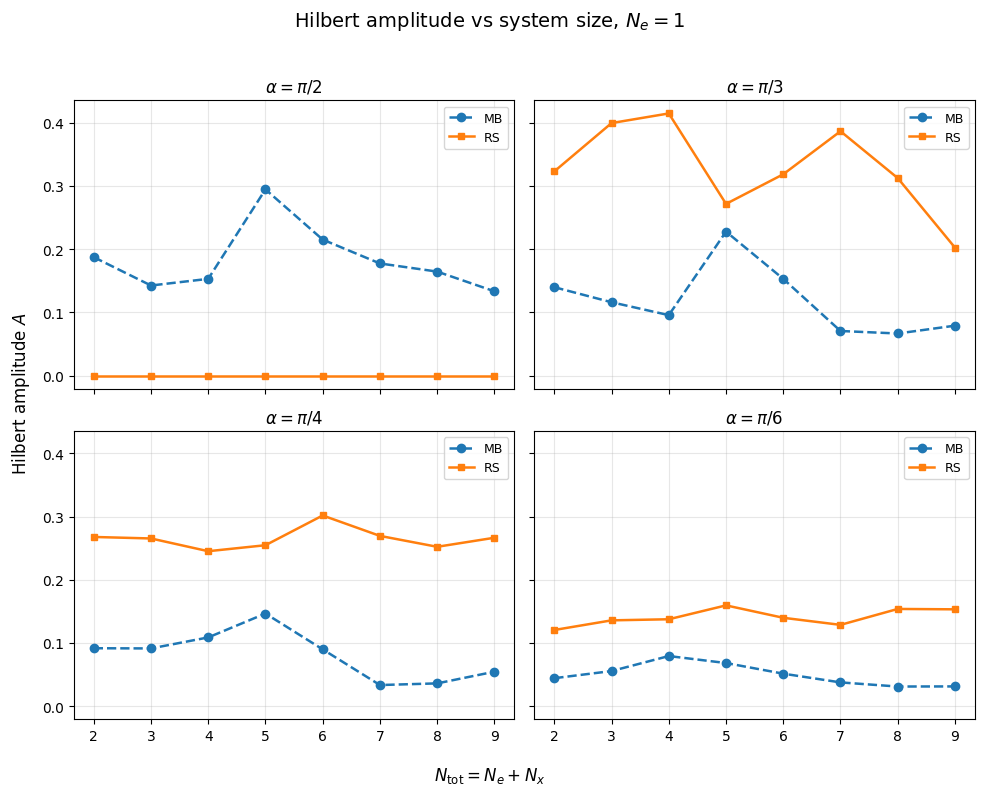

In [49]:
# ============================================================
# CELL 16: Plot Hilbert amplitude vs N (4-panel version)
# ============================================================

if len(amp_freq_records) == 0:
    raise RuntimeError("Run Cell 15 first.")

# x-axis choice:
#   "Ntot" or "Nx"
plot_N_axis = "Ntot"

if plot_N_axis == "Ntot":
    x_key = "Ntot"
    x_label = r"$N_{\rm tot}=N_e+N_x$"
elif plot_N_axis == "Nx":
    x_key = "Nx"
    x_label = r"$N_x$"
else:
    raise ValueError("plot_N_axis must be 'Ntot' or 'Nx'.")

# Order of panels
alpha_order = [r"\pi/2", r"\pi/3", r"\pi/4", r"\pi/6"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, alpha_label in zip(axes, alpha_order):

    sub = [r for r in amp_freq_records if r["alpha_label"] == alpha_label]

    if len(sub) == 0:
        ax.set_visible(False)
        continue

    sub = sorted(sub, key=lambda r: r[x_key])

    x = np.array([r[x_key] for r in sub], dtype=float)
    A_MB = np.array([r["A_MB"] for r in sub], dtype=float)
    A_RS = np.array([r["A_RS"] for r in sub], dtype=float)

    ax.plot(
        x,
        A_MB,
        "o--",
        linewidth=1.8,
        markersize=6,
        label="MB",
    )

    ax.plot(
        x,
        A_RS,
        "s-",
        linewidth=1.8,
        markersize=5,
        label="RS",
    )

    ax.set_title(rf"$\alpha={alpha_label}$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

# Common labels
fig.supxlabel(x_label)
fig.supylabel(r"Hilbert amplitude $A$")
fig.suptitle(rf"Hilbert amplitude vs system size, $N_e={fixed_Ne}$", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

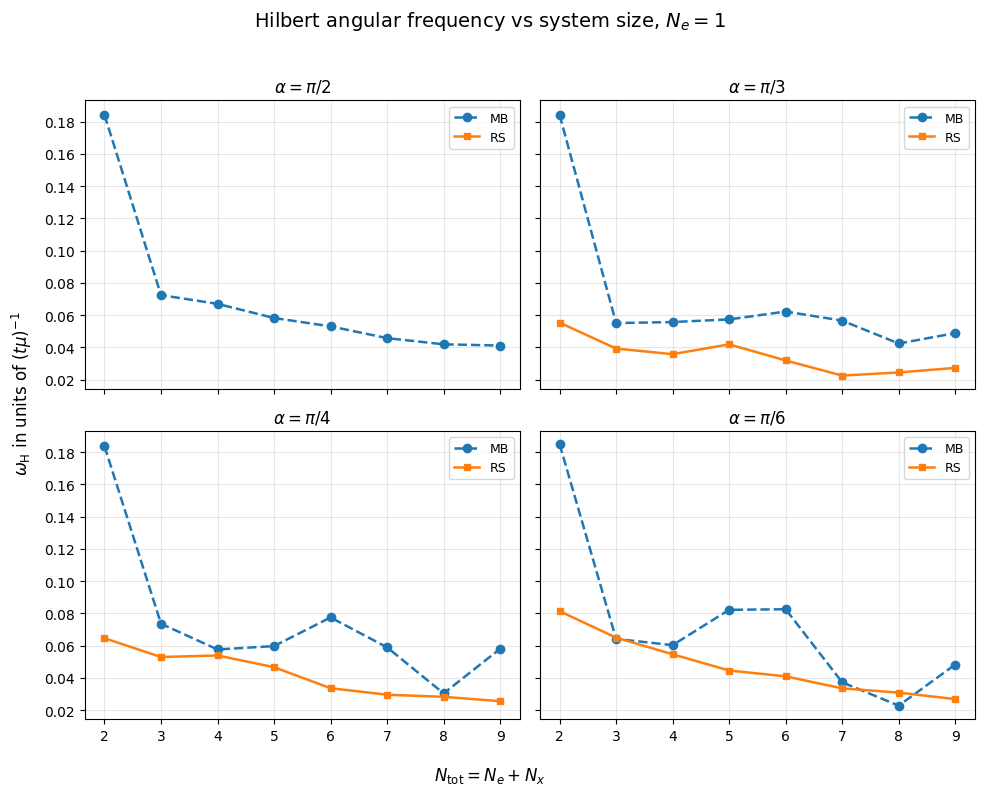

In [50]:
# ============================================================
# CELL 17: Plot Hilbert angular frequency vs N (4-panel version)
# ============================================================

if len(amp_freq_records) == 0:
    raise RuntimeError("Run Cell 15 first.")

# Order of panels
alpha_order = [r"\pi/2", r"\pi/3", r"\pi/4", r"\pi/6"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, alpha_label in zip(axes, alpha_order):

    sub = [r for r in amp_freq_records if r["alpha_label"] == alpha_label]

    if len(sub) == 0:
        ax.set_visible(False)
        continue

    sub = sorted(sub, key=lambda r: r[x_key])

    x = np.array([r[x_key] for r in sub], dtype=float)
    omega_MB = np.array([r["omega_MB"] for r in sub], dtype=float)
    omega_RS = np.array([r["omega_RS"] for r in sub], dtype=float)

    ax.plot(
        x,
        omega_MB,
        "o--",
        linewidth=1.8,
        markersize=6,
        label="MB",
    )

    ax.plot(
        x,
        omega_RS,
        "s-",
        linewidth=1.8,
        markersize=5,
        label="RS",
    )

    ax.set_title(rf"$\alpha={alpha_label}$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

# Common labels
fig.supxlabel(x_label)
fig.supylabel(omega_label_h)
fig.suptitle(
    rf"Hilbert angular frequency vs system size, $N_e={fixed_Ne}$",
    fontsize=14,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()